In [52]:
import numpy as np 
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader,Dataset

In [9]:
#function to extract the data from the files, taken from the official toronto.edu website
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict


In [10]:
#location of files
file1='cifar-10-batches-py/data_batch_1'
file2='cifar-10-batches-py/data_batch_2'
file3='cifar-10-batches-py/data_batch_3'
file4='cifar-10-batches-py/data_batch_4'
file5='cifar-10-batches-py/data_batch_5'

In [12]:
#storing data of each image 
db1=unpickle(file1)
db2=unpickle(file2)
db3=unpickle(file3)
db4=unpickle(file4)
db5=unpickle(file5)

In [13]:
filet='cifar-10-batches-py/test_batch'
test=unpickle(filet)

In [21]:
db1

{b'batch_label': b'training batch 1 of 5',
 b'labels': [6,
  9,
  9,
  4,
  1,
  1,
  2,
  7,
  8,
  3,
  4,
  7,
  7,
  2,
  9,
  9,
  9,
  3,
  2,
  6,
  4,
  3,
  6,
  6,
  2,
  6,
  3,
  5,
  4,
  0,
  0,
  9,
  1,
  3,
  4,
  0,
  3,
  7,
  3,
  3,
  5,
  2,
  2,
  7,
  1,
  1,
  1,
  2,
  2,
  0,
  9,
  5,
  7,
  9,
  2,
  2,
  5,
  2,
  4,
  3,
  1,
  1,
  8,
  2,
  1,
  1,
  4,
  9,
  7,
  8,
  5,
  9,
  6,
  7,
  3,
  1,
  9,
  0,
  3,
  1,
  3,
  5,
  4,
  5,
  7,
  7,
  4,
  7,
  9,
  4,
  2,
  3,
  8,
  0,
  1,
  6,
  1,
  1,
  4,
  1,
  8,
  3,
  9,
  6,
  6,
  1,
  8,
  5,
  2,
  9,
  9,
  8,
  1,
  7,
  7,
  0,
  0,
  6,
  9,
  1,
  2,
  2,
  9,
  2,
  6,
  6,
  1,
  9,
  5,
  0,
  4,
  7,
  6,
  7,
  1,
  8,
  1,
  1,
  2,
  8,
  1,
  3,
  3,
  6,
  2,
  4,
  9,
  9,
  5,
  4,
  3,
  6,
  7,
  4,
  6,
  8,
  5,
  5,
  4,
  3,
  1,
  8,
  4,
  7,
  6,
  0,
  9,
  5,
  1,
  3,
  8,
  2,
  7,
  5,
  3,
  4,
  1,
  5,
  7,
  0,
  4,
  7,
  5,
  5,
  1,
  0,
  9,
  6,
  9,
 

In [15]:
db1.keys()

dict_keys([b'batch_label', b'labels', b'data', b'filenames'])

In [17]:
db1[b'data'].shape

(10000, 3072)

In [18]:
#one dataset contains 10000 images with 3072 integers which describe these images. 3072 --> 3*32*32 where 3 is the number of channels of colors (r,g,b)
# 32*32 is the resolution of the image

In [90]:
print(np.array(db1[b'labels']).shape)

(10000,)


In [ ]:
# stacking the data together
data=np.vstack([db1[b'data'],db2[b'data'],db3[b'data'],db4[b'data'],db5[b'data']])
labels=np.vstack([db1[b'labels'],db2[b'labels'],db3[b'labels'],db4[b'labels'],db5[b'labels']])


In [91]:
print(labels.shape)
print(data.shape)
labels=labels.reshape(-1)
print(labels.shape)

(5, 10000)
(50000, 3, 32, 32)
(50000,)


In [92]:
data=data.reshape(50000,3,32,32) #color panels,resolutions
data

array([[[[ 59,  43,  50, ..., 158, 152, 148],
         [ 16,   0,  18, ..., 123, 119, 122],
         [ 25,  16,  49, ..., 118, 120, 109],
         ...,
         [208, 201, 198, ..., 160,  56,  53],
         [180, 173, 186, ..., 184,  97,  83],
         [177, 168, 179, ..., 216, 151, 123]],

        [[ 62,  46,  48, ..., 132, 125, 124],
         [ 20,   0,   8, ...,  88,  83,  87],
         [ 24,   7,  27, ...,  84,  84,  73],
         ...,
         [170, 153, 161, ..., 133,  31,  34],
         [139, 123, 144, ..., 148,  62,  53],
         [144, 129, 142, ..., 184, 118,  92]],

        [[ 63,  45,  43, ..., 108, 102, 103],
         [ 20,   0,   0, ...,  55,  50,  57],
         [ 21,   0,   8, ...,  50,  50,  42],
         ...,
         [ 96,  34,  26, ...,  70,   7,  20],
         [ 96,  42,  30, ...,  94,  34,  34],
         [116,  94,  87, ..., 140,  84,  72]]],


       [[[154, 126, 105, ...,  91,  87,  79],
         [140, 145, 125, ...,  96,  77,  71],
         [140, 139, 115, ..., 

In [93]:
data = data.transpose(0,2,3,1)
data.shape

(50000, 32, 32, 3)

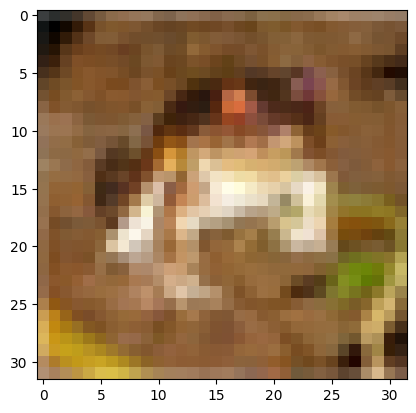

In [94]:
plt.imshow(data[0])

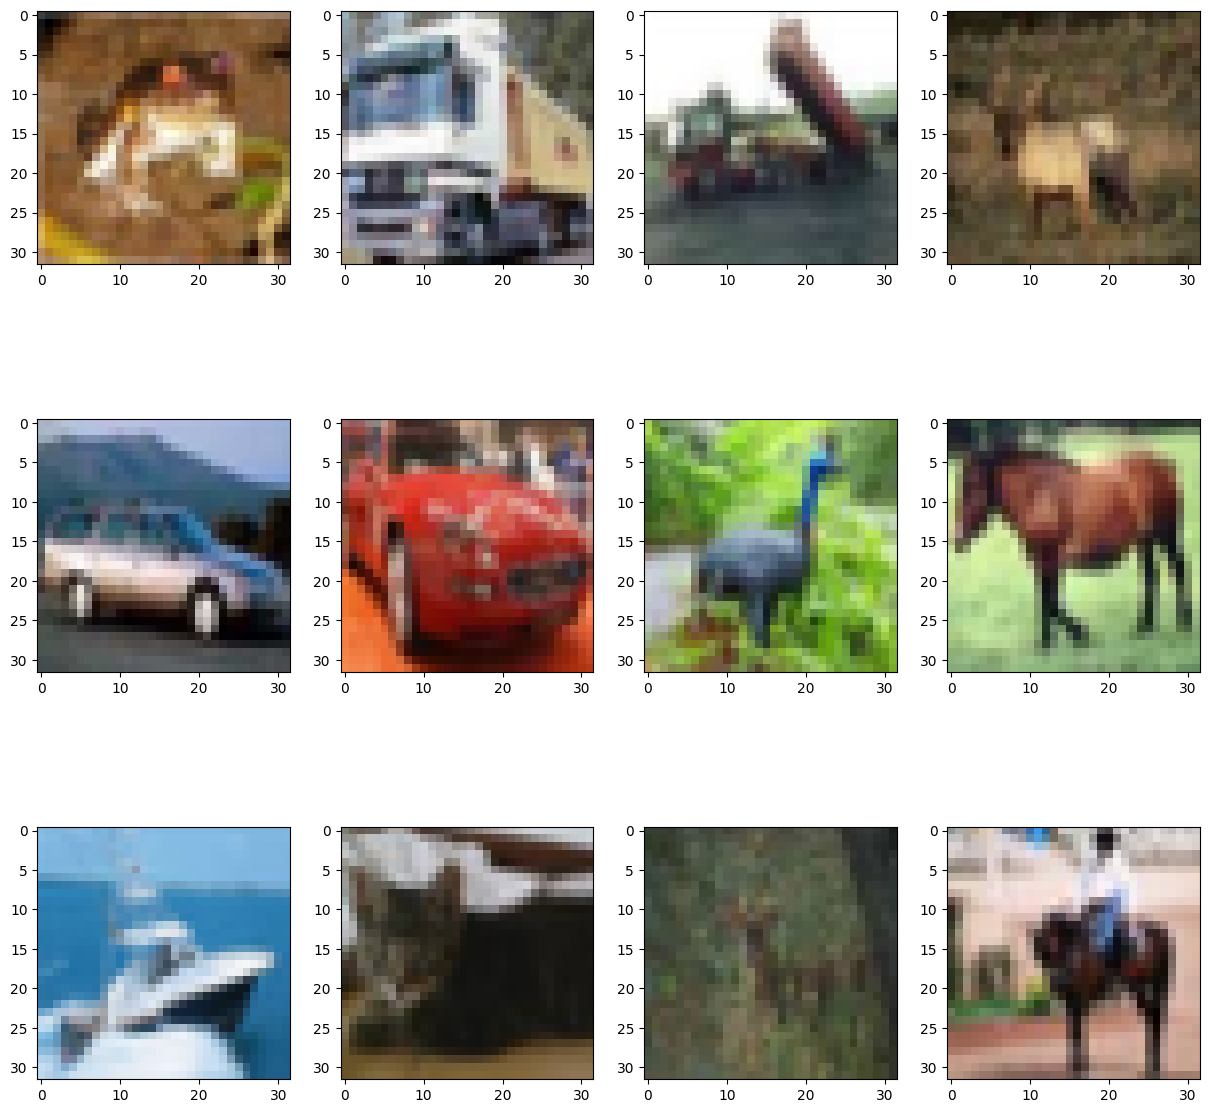

In [95]:
plt.figure(figsize=(15,15))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(data[i])
plt.savefig("datavis.png")
plt.show()

In [96]:
#seeing the labels present in the dataset
labels_,count=np.unique(labels,return_counts=True)
print(labels_)
print(count)

[0 1 2 3 4 5 6 7 8 9]
[5000 5000 5000 5000 5000 5000 5000 5000 5000 5000]


In [97]:
# ALL the CLASSES HAVE SAME REPRESENTATION OVER THE DATASET SO THERE IS NO NEED FOR AUGMENTATION TO FILL THE MISSING DATA

In [98]:
meta = unpickle('cifar-10-batches-py/batches.meta')
CLASSES = [c.decode('utf-8') for c in meta[b'label_names']]
print(CLASSES)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [99]:
# THE DATASET COMPRISES OF 10 CLASSES WHICH ARE LISTED ABOVE

In [100]:
print(data.shape)
print(len(labels))

(50000, 32, 32, 3)
50000


In [101]:
#creating dataset class
class dataset(Dataset):
    def __init__(self,imgdata,labels,transform=None):
        self.imgdata=imgdata
        self.labels=labels
        self.transform=transform 
    def __len__(self):
        return len(self.imgdata)
    def __getitem__(self,i):
        img_=torch.from_numpy(self.imgdata[i]).float() / 255.0
        img_= img_*2-1     
        labels_=self.labels[i]
        if self.transform!=None:
            img_=self.transform(img_)
        return img_,labels_

In [102]:
data=data.transpose(0,3,1,2)
data.shape

(50000, 3, 32, 32)

In [103]:
train_data=DataLoader(dataset(data,labels),batch_size=32,shuffle=True)
val_data=DataLoader(dataset(data,labels),batch_size=32,shuffle=False)

In [105]:
from diffusers import UNet2DModel, DDPMScheduler, DDPMPipeline

In [106]:
#using a pretrained unet and linear noise scheduler
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [107]:
Unet=UNet2DModel.from_pretrained('google/ddpm-cifar10-32').to(device)
scheduler=DDPMScheduler.from_pretrained('google/ddpm-cifar10-32')

C:\Users\divya\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\utils\_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


In [108]:
print(scheduler.config)

FrozenDict({'num_train_timesteps': 1000, 'beta_start': 0.0001, 'beta_end': 0.02, 'beta_schedule': 'linear', 'trained_betas': None, 'variance_type': 'fixed_large', 'clip_sample': True, 'prediction_type': 'epsilon', 'thresholding': False, 'dynamic_thresholding_ratio': 0.995, 'clip_sample_range': 1.0, 'sample_max_value': 1.0, 'timestep_spacing': 'leading', 'steps_offset': 0, 'rescale_betas_zero_snr': False, '_use_default_values': ['rescale_betas_zero_snr', 'thresholding', 'clip_sample_range', 'steps_offset', 'sample_max_value', 'prediction_type', 'timestep_spacing', 'dynamic_thresholding_ratio'], '_class_name': 'DDPMScheduler', '_diffusers_version': '0.1.1'})


In [112]:
import tqdm 
def train(model,scheduler,train_data,val_data,epochs=20,lr=1e-4):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model=model.to(device)
    train_loss=[]
    val_loss=[]
    T=scheduler.config.num_train_timesteps
    optimizer=torch.optim.Adam(model.parameters(),lr=lr,weight_decay=1e-5)
    for epoch in range(epochs):
        model.train()
        total_loss=0
        for img,labels in tqdm.tqdm(train_data,desc=f'Epoch:{epoch+1}',leave=False):
            img=img.to(device)
            optimizer.zero_grad()
            t=torch.randint(0,T,(img.shape[0],),device=device).long()
            noise=torch.randn_like(img)
            x_t=scheduler.add_noise(img,noise,t)
            pred_noise=model(x_t,t).sample
            loss=F.mse_loss(pred_noise,noise)
            loss.backward()
            optimizer.step()
            total_loss+=loss.item()
        avg_loss=total_loss/len(train_data)
        train_loss.append(avg_loss)
        model.eval()
        v_loss=0
        with torch.no_grad():
            for img,_ in val_data:
                img=img.to(device)
                t=torch.randint(0,T,(img.shape[0],),device=device).long()
                noise=torch.randn_like(img)
                x_t=scheduler.add_noise(img,noise,t)
                pred_noise=model(x_t,t).sample
                loss=F.mse_loss(pred_noise,noise)
                v_loss+=loss.item()
            val_loss.append(v_loss/len(val_data))
        print(f"For Epoch {epoch+1} , Avg train loss = {train_loss[-1]:.8f} , Avg validation loss = {val_loss[-1]:.8f}")

    return train_loss,val_loss
        

In [113]:
epoch = 20
lr = 1e-5

In [115]:
import gc
torch.cuda.empty_cache()
gc.collect()

41981

In [116]:
train_loss,val_loss=train(Unet,scheduler,train_data,val_data,epoch,lr)

For Epoch 1 , Avg train loss = 0.02755659 , Avg validation loss = 0.02701368


For Epoch 2 , Avg train loss = 0.02754271 , Avg validation loss = 0.02805363


For Epoch 3 , Avg train loss = 0.02748534 , Avg validation loss = 0.02760429


For Epoch 4 , Avg train loss = 0.02754121 , Avg validation loss = 0.02782523


For Epoch 5 , Avg train loss = 0.02778786 , Avg validation loss = 0.02790694


...

For Epoch 16 , Avg train loss = 0.02918584 , Avg validation loss = 0.02973563


For Epoch 17 , Avg train loss = 0.02919927 , Avg validation loss = 0.02960592


For Epoch 18 , Avg train loss = 0.02951906 , Avg validation loss = 0.02933052


For Epoch 19 , Avg train loss = 0.02958582 , Avg validation loss = 0.02940116


For Epoch 20 , Avg train loss = 0.02950837 , Avg validation loss = 0.02978450


In [117]:
torch.save(Unet.state_dict(),"unetft.pth")